# Лабораторная 1
## Методы дихотомии и золотого сечения
### Задачи
1) График целевой функции
2) Точность eps, количество итераций, количество вычисленных значений целевой функции, точка минимума
3) Графики зависимости ln от n для обоих методов в одной системе координат 
### Контрольные вопросы
1) Постановка задачи
2) Алгоритмы методов
3) Сравнение методов

(используем дихотомию для высокой точности)
(используем золотое сечение при тяжелых функциях)

### График целевой функции

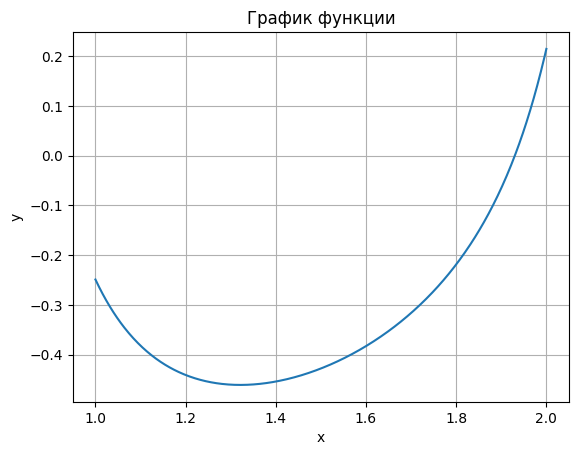

In [34]:
import matplotlib.pyplot as plt
from typing import List, Tuple
import numpy as np
import math


def f(x):
    R1 = math.atan(x**3 - 5*x + 1)
    R2 = (x**2 / (3*x - 2)) ** math.sqrt(3)
    return R1 + R2

x_list = np.linspace(1, 2, 500)
results = [f(x) for x in x_list]

plt.plot(x_list, results)
plt.title('График функции')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


### Поиск минимума методом дихотомии

In [55]:
# есть a и b, расстояние между ними = l
# если расстояние l <= eps - выход
# берём середину графика l/2
# отсупаем влево и вправо от неё на d получая x1 и x2
# находим y1 = f(x1) и y2 = f(x2)
# если y1 < y2, то b = x2
# если y1 > y2, то a = x1

eps = 0.000001
d = eps / 4

a = 1
b = 2
l = b - a
y1 = 0
y2 = 0

print("Метод дихотомии")
print(f"Точность: {eps}")
print(f"Количество итераций: {math.ceil(math.log2((l-2*d)/(eps-2*d)))}")

def dichotomy(a: float, b: float, eps: float) -> Tuple[Tuple[float, float], int, List[int]]:
    d = eps / 4
    l = b - a
    y1 = 0
    y2 = 0

    f_counter = 0
    iterations_lens = []
    while l > eps:
        iterations_lens.append(l)

        x0 = a + l / 2
        x1 = x0 - d
        x2 = x0 + d

        y1 = f(x1)
        y2 = f(x2)
        f_counter += 2
        if y1 <= y2:
            b = x2
        else:
            a = x1
        l = b - a
    x = (a + b) / 2
    y = f(x)
    answer = (x, y)
    return answer, f_counter, iterations_lens

answer, f_counter, dichotomy_iterations_lens = dichotomy(a, b, eps)
print(f"количество вычисленных значений целевой функции: {f_counter}")
print(f"Точка минимума ({answer[0]:.12f}, {answer[1]:.12f})")

Метод дихотомии
Точность: 1e-06
Количество итераций: 21
количество вычисленных значений целевой функции: 42
Точка минимума (1.321161121143, -0.460964595934)


### Поиск минимума методом золотого сечения

In [78]:
# есть a и b, расстояние между ними = l
# если расстояние l <= eps - выход
# x1 = b − τ(b − a)
# x2 = a + τ(b − a)
# f(x1) < f(x2) → минимум слева → b=x2
# иначе → минимум справа → a=x1
# отсупаем влево и вправо от неё на d получая x1 и x2
# находим y1 = f(x1) и y2 = f(x2)
# если y1 < y2, то b = x2
# если y1 > y2, то a = x1

eps = 0.000001

a = 1
b = 2

print("Метод золотого сечения")
print(f"Точность: {eps}")

t = (math.sqrt(5) - 1) / 2
n = math.ceil(math.log((b - a)/eps) / math.log(1/t))
print(f"Количество итераций: {n}")

def golden_ratio(a: float, b: float, eps: float) -> Tuple[Tuple[float, float], int, List[int]]:
    t = (math.sqrt(5) - 1) / 2
    l = b - a
    x1 = b - t * l
    x2 = a + t * l
    y1 = f(x1)
    y2 = f(x2)

    iterations_lens = []
    f_counter = 2
    while l > eps:
        iterations_lens.append(l)
        if y1 < y2:
            b = x2
            l = b - a
            x2 = x1
            y2 = y1
            x1 = b - t * l
            y1 = f(x1)
        else:
            a = x1
            l = b - a
            x1 = x2
            y1 = y2
            x2 = a + t * l
            y2 = f(x2)
        f_counter += 1
    x = (a + b) / 2
    y = f(x)
    answer = (x, y)
    return answer, f_counter, iterations_lens

answer, f_counter, golden_iterations_lens = golden_ratio(a, b, eps)
print(f"количество вычисленных значений целевой функции: {f_counter}")
print(f"Точка минимума ({answer[0]:.12f}, {answer[1]:.12f})")

Метод золотого сечения
Точность: 1e-06
Количество итераций: 29
количество вычисленных значений целевой функции: 31
Точка минимума (1.321161448954, -0.460964595934)


### Графики зависимости ln от n для обоих методов в одной системе координат

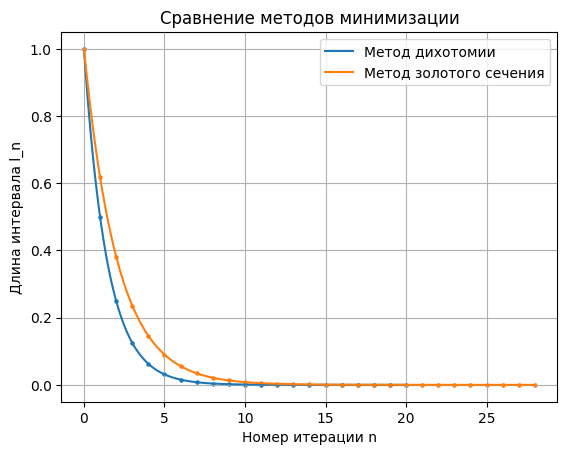

In [77]:
import numpy as np
import matplotlib.pyplot as plt

def make_plot(iterations_lens, label):
    x = np.array(range(len(iterations_lens)))
    y = np.array(iterations_lens)

    coeffs = np.polyfit(x, y, 10)
    poly = np.poly1d(coeffs)

    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = poly(x_smooth)
    
    plt.scatter(x, y, s=5)
    plt.plot(x_smooth, y_smooth, label=label)

make_plot(dichotomy_iterations_lens, "Метод дихотомии")
make_plot(golden_iterations_lens, "Метод золотого сечения")

plt.xlabel("Номер итерации n")
plt.ylabel("Длина интервала l_n")
plt.title("Сравнение методов минимизации")
plt.legend()
plt.grid(True)
plt.show()